# RBL-4 full analysis: GPT vs retained EvoSuite baseline

## tl;dr

The live zero-shot GPT run generated 63/63 suites, but only 14/63 passed after the permitted repair process. Its aggregate branch coverage was 18.90% and aggregate mutation score was 16.21%. The existing EvoSuite 1/3/5-minute test archives were measured per SUT, enabling the planned paired Wilcoxon tests with Holm correction for RQ3. None of the six RQ3 comparisons was significant after Holm correction; the closest result was mutation at 5 minutes (raw p=0.06251, Holm p=0.37505). EvoSuite remains an operational technical comparator, not a student-test proxy.

## Context & Methods

### Key assumptions

- GPT data are the actual 2026-07-16 API, Maven, JaCoCo, and PIT artifacts in this workspace.
- Non-executable GPT suites are retained and recorded as failures; they are not used to execute coverage/PIT.
- The EvoSuite source is the existing 1/3/5-minute test archive; no EvoSuite generation is run in this analysis.
- The three archives are remeasured per SUT using Maven, JaCoCo, and PIT under Temurin JDK 8, which EvoSuite 1.0.6 requires.
- RQ3 pairs only suites that pass in both tools; three technical mutation exclusions remain excluded from mutation comparisons.

The analysis script records hashes and input paths in `results/rbl4_data_provenance.md`.

## Data

### 1. Rebuild analysis artefacts from retained inputs

In [1]:
from pathlib import Path
import subprocess
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts' / 'generate_rbl4_analysis.py').is_file():
    ROOT = ROOT.parent
subprocess.run([sys.executable, str(ROOT / 'scripts' / 'generate_rbl4_analysis.py')], check=True)
print(ROOT)

F:\Ky 5\SWT301\Github\SE1944_LLM_Unit_Test_Generation


### 2. Load the verified analysis tables

In [2]:
import pandas as pd
from IPython.display import display, Image

gpt = pd.read_csv(ROOT / 'results' / 'metrics' / 'gpt_class_metrics.csv')
summary = pd.read_csv(ROOT / 'results' / 'summary.csv')
status = pd.read_csv(ROOT / 'results' / 'full_compile_status.csv')
evo = pd.read_csv(ROOT / 'results' / 'metrics' / 'evosuite_measured_aggregate.csv')
display(status['status'].value_counts().rename_axis('status').to_frame('suites'))
display(evo)

,suites
status,
FAIL_ASSERTION,47
PASS,14
FAIL_COMPILE,2


,tool,budget_min,branch_covered,branch_total,branch_coverage_pct,mutation_killed,mutation_total,mutation_score_pct,pass_suites,measurement_source,java_runtime
0,EvoSuite,1,688,762,90.288714,610,833,73.229292,63,archive/evosuite_1p,Temurin JDK 8.0.492
1,EvoSuite,3,730,762,95.800525,638,833,76.590636,63,archive/evosuite_3p,Temurin JDK 8.0.492
2,EvoSuite,5,757,762,99.343832,684,833,82.112845,63,archive/evosuite_5p,Temurin JDK 8.0.492


## Results

### 3. Hypothesis-test and descriptive outputs

In [3]:
display(summary[['rq', 'status', 'n', 'p_raw', 'gpt_value', 'comparator_value', 'delta_pp', 'conclusion']])

,rq,status,n,p_raw,gpt_value,comparator_value,delta_pp,conclusion
0,RQ1,TESTED,63,0.942967,18.897638,30.220000,-11.322362,NOT_SUPPORTED
1,RQ2_floor,TESTED,60,0.952447,16.206483,4.000000,12.206483,NOT_SUPPORTED
2,RQ2_target,TESTED,60,0.997231,16.206483,40.210000,-24.003517,NOT_SUPPORTED
3,RQ4,TESTED,63,1.000000,20.634921,50.000000,-29.365079,NOT_SUPPORTED
4,RQ3_1m_branch,TESTED,14,0.179712,98.086735,99.404762,-1.318027,NO_SIGNIFICANT_DIFFERENCE
5,RQ3_1m_mutation,TESTED,13,0.204084,88.209824,79.136846,9.072978,NO_SIGNIFICANT_DIFFERENCE
6,RQ3_3m_branch,TESTED,14,0.179712,98.086735,99.404762,-1.318027,NO_SIGNIFICANT_DIFFERENCE
7,RQ3_3m_mutation,TESTED,13,0.236724,88.209824,78.202780,10.007044,NO_SIGNIFICANT_DIFFERENCE
8,RQ3_5m_branch,TESTED,14,0.179712,98.086735,99.404762,-1.318027,NO_SIGNIFICANT_DIFFERENCE
9,RQ3_5m_mutation,TESTED,13,0.062509,88.209824,82.403964,5.805861,NO_SIGNIFICANT_DIFFERENCE


### 4. Visual evidence

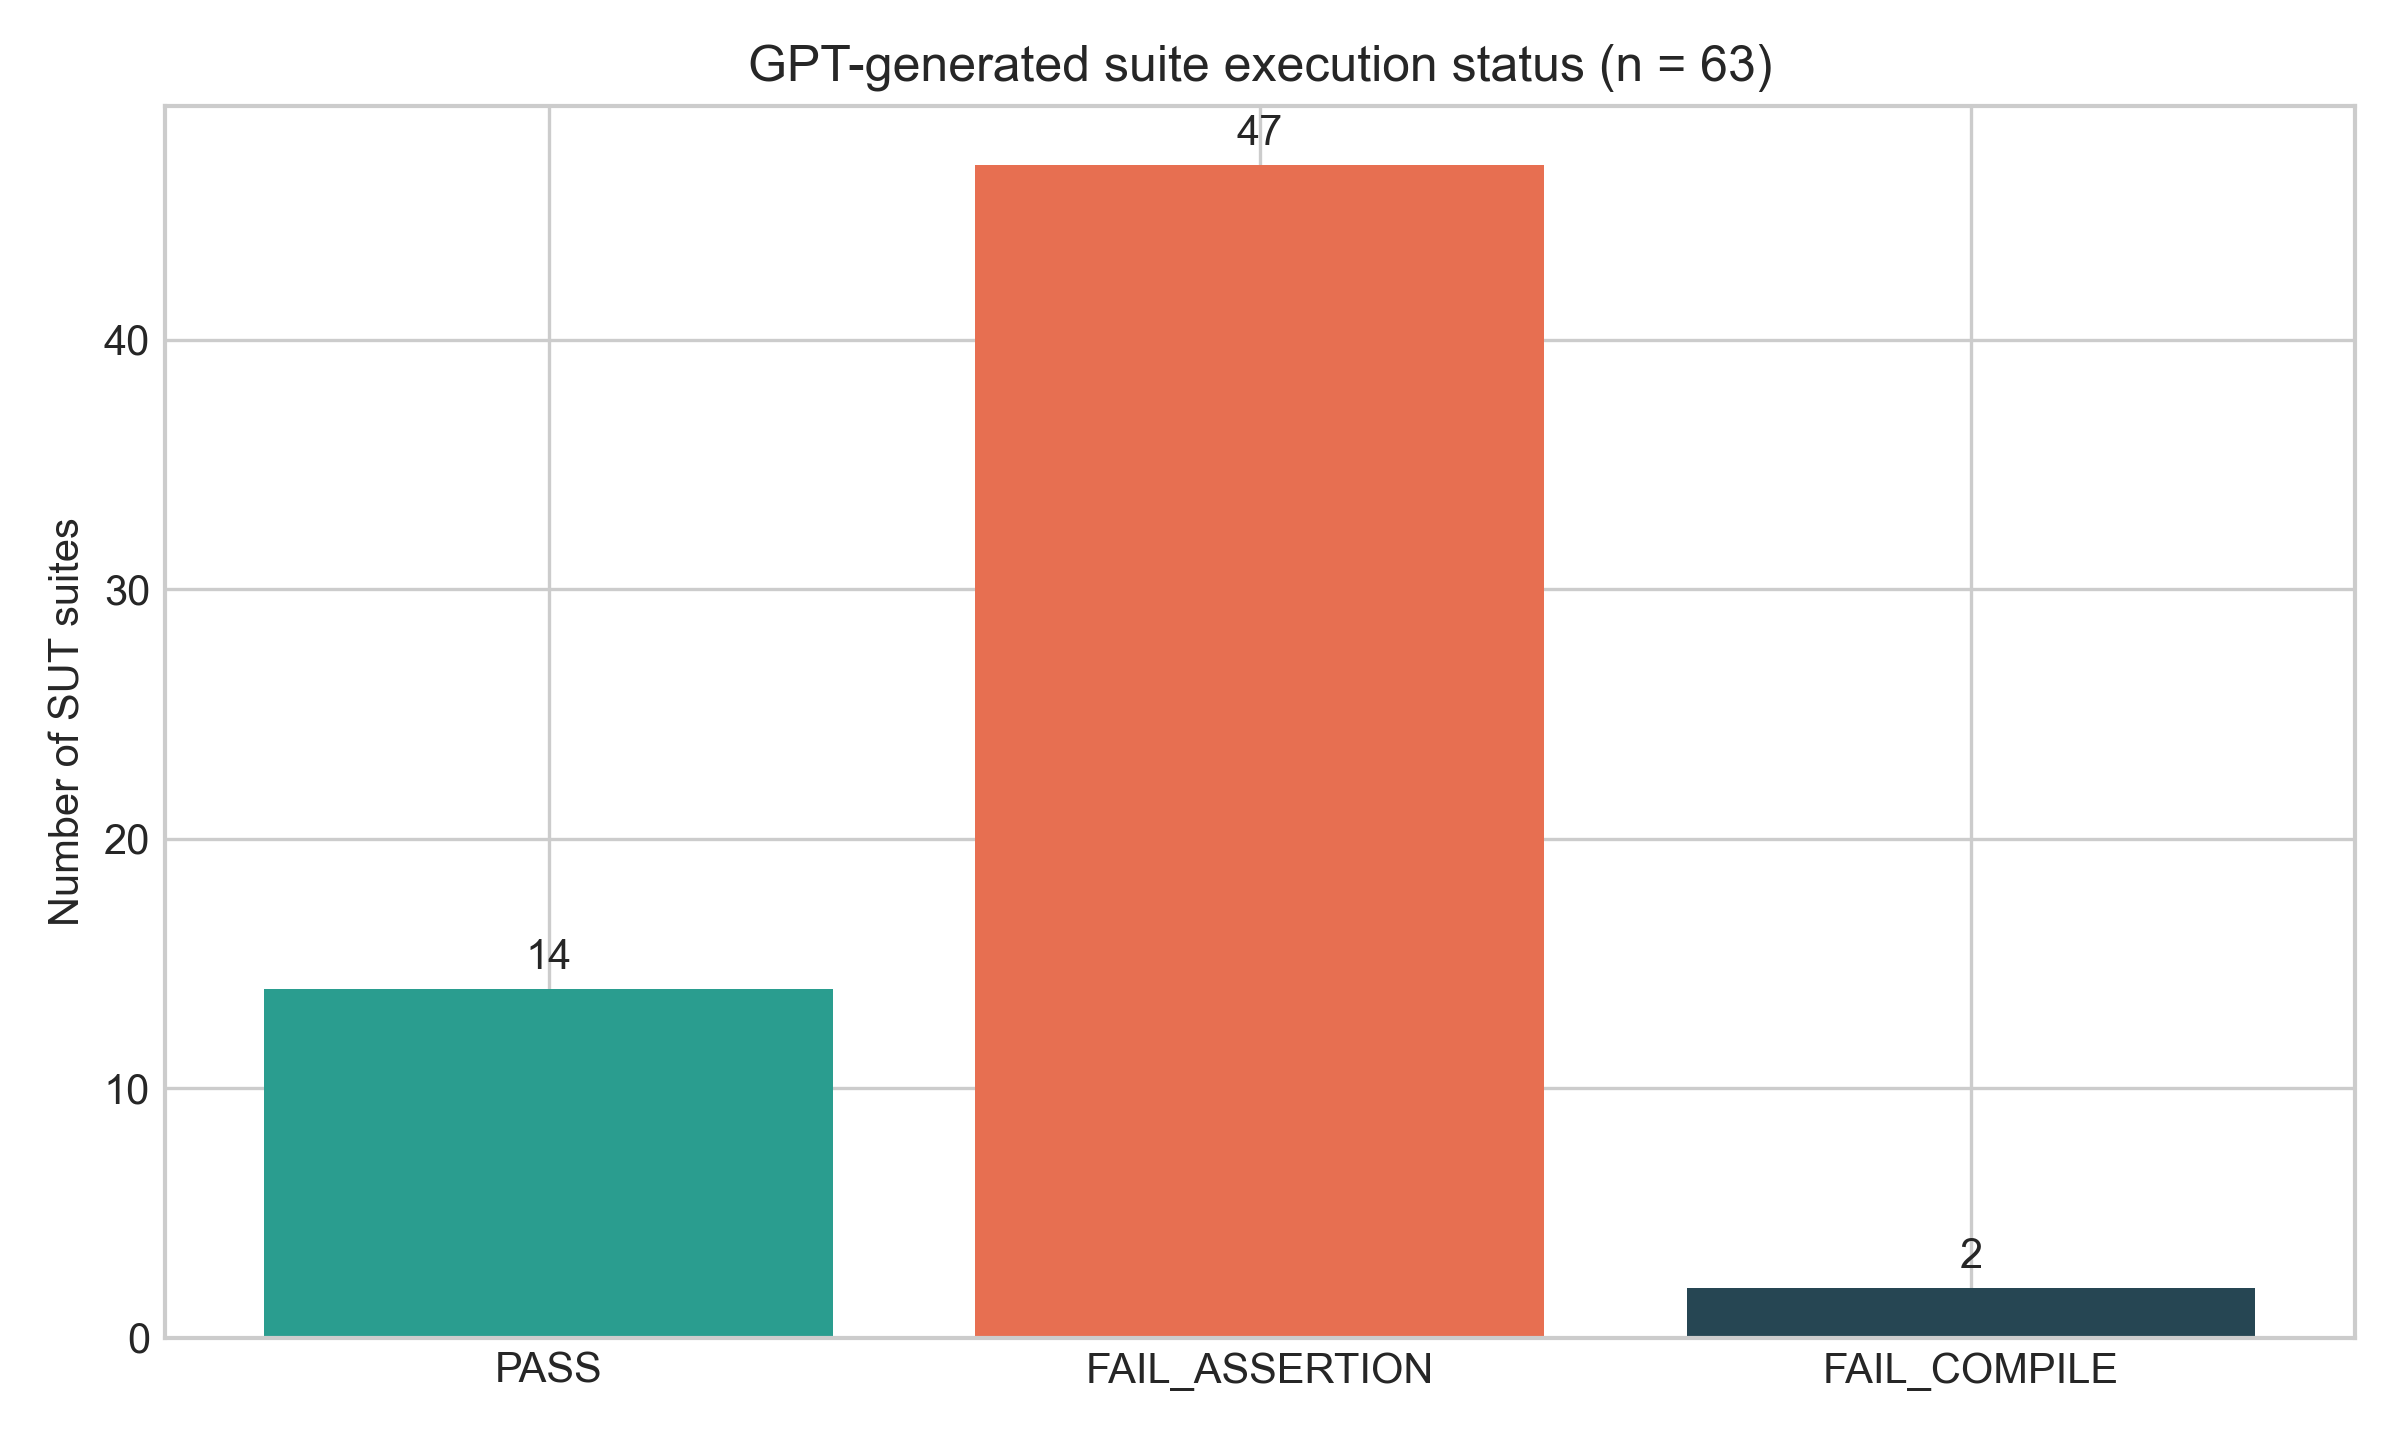

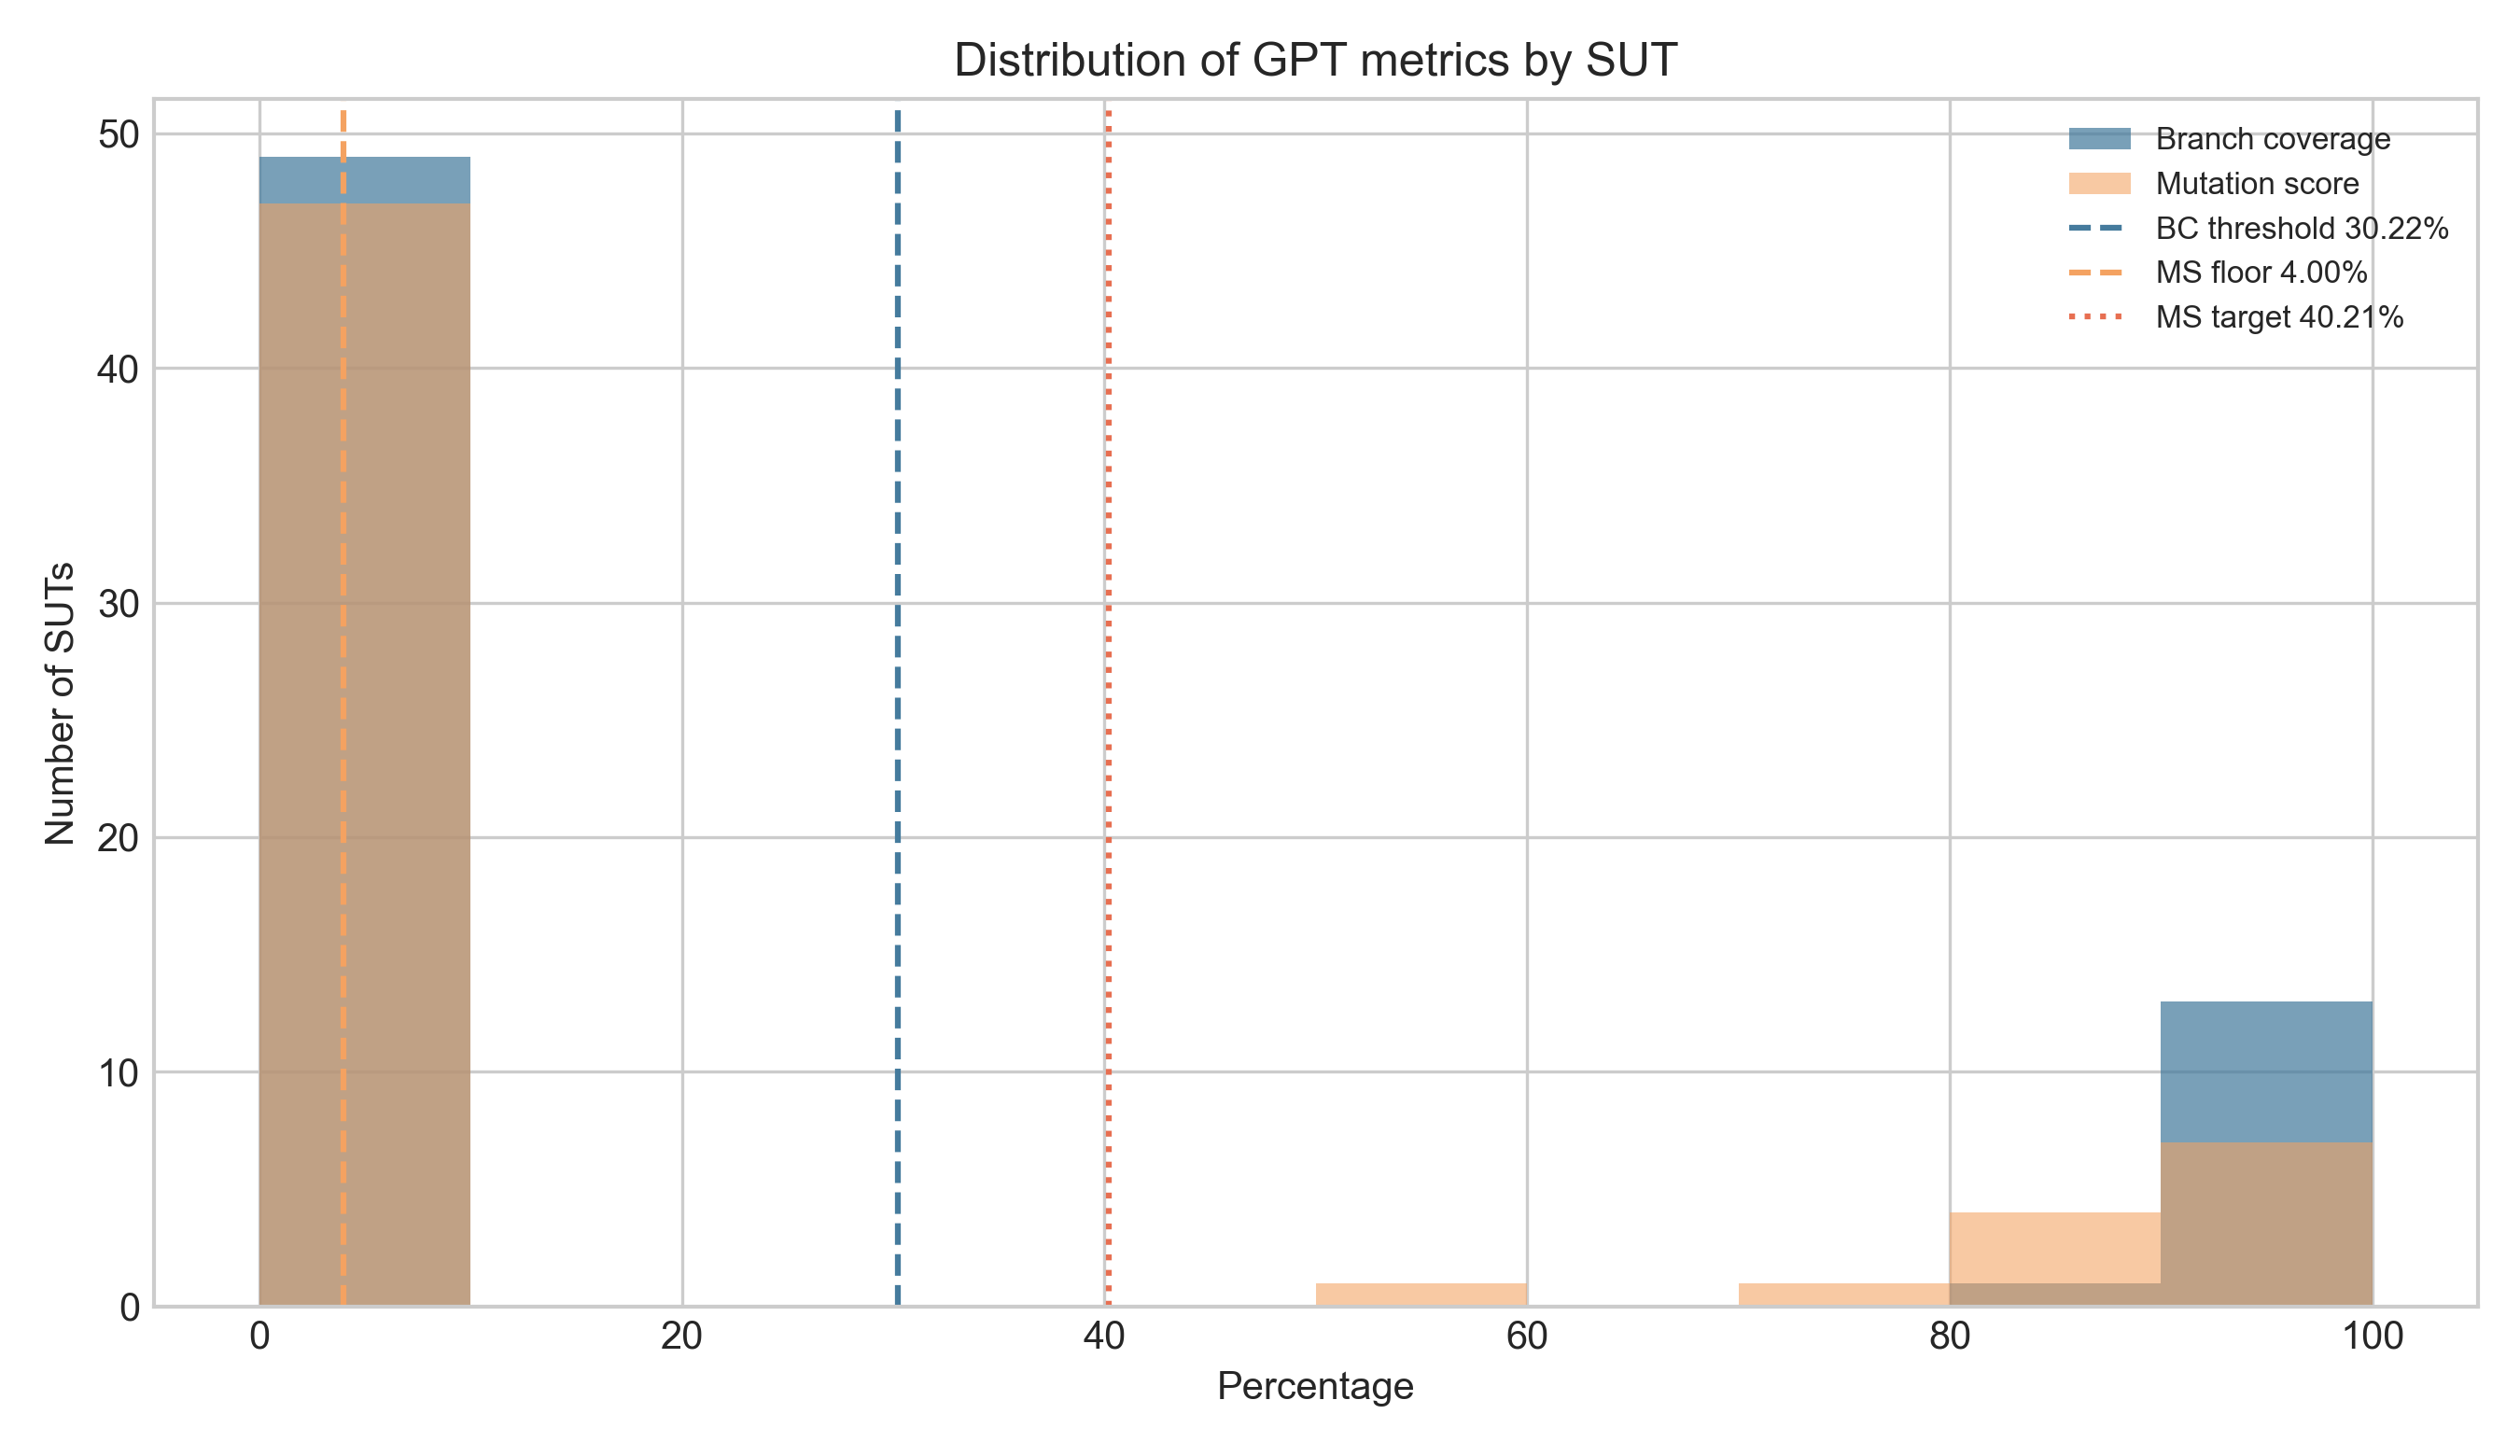

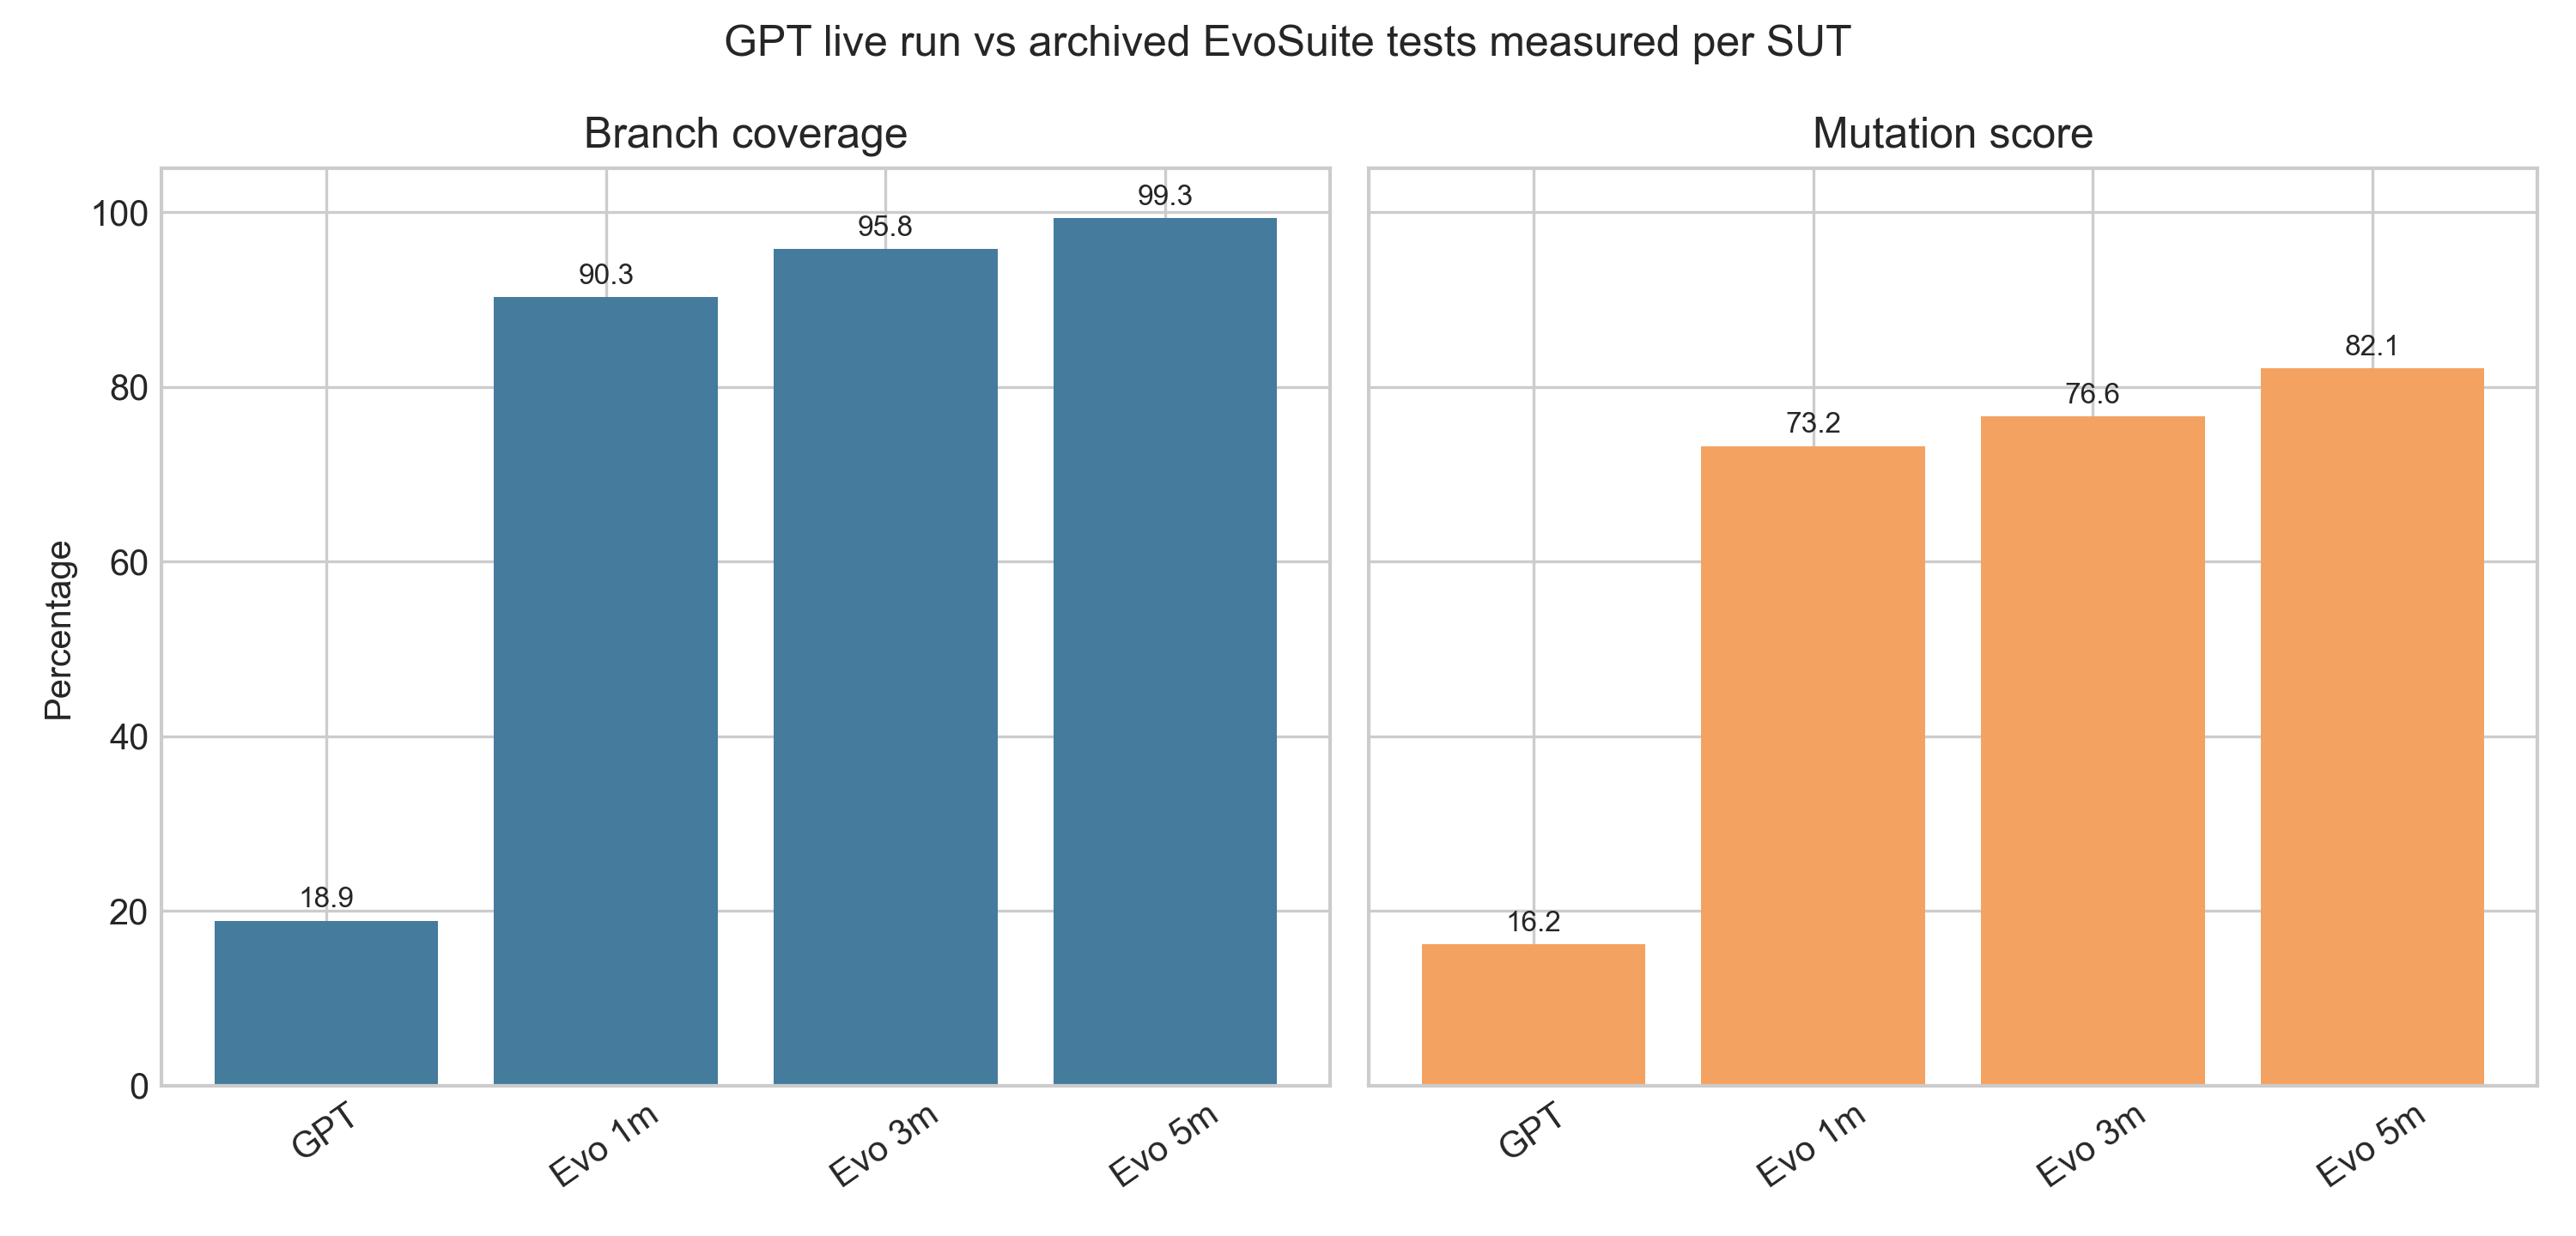

In [4]:
for filename in [
    'fig1_execution_status.png',
    'fig2_gpt_metric_distribution.png',
    'fig3_gpt_vs_evosuite_paired.png',
]:
    display(Image(filename=str(ROOT / 'results' / 'figures' / filename)))

## Takeaways

- RQ1 was not supported: the aggregate GPT branch coverage (18.90%) was below the 30.22% threshold.
- The aggregate GPT mutation score (16.21%) exceeded the 4.00% floor, but the per-SUT one-sided Wilcoxon result was not supported because the distribution includes many zero-metric non-executable suites. It did not meet the 40.21% target.
- RQ4 was not supported: 13/63 SUTs (20.63%) simultaneously passed and met both floor thresholds.
- RQ3 uses two-sided paired Wilcoxon tests with Holm correction. The summary table distinguishes all passing pairs from the non-zero differences ranked by Wilcoxon.
- EvoSuite must never be described as student-written benchmark data; the student comparison remains deferred.